In [2]:
%matplotlib widget

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import mpl_interactions as pli

In [4]:
import nrrd
import numpy as np
from skimage.metrics import structural_similarity as compare_ssim

# Load the NRRD volumes
volume4, _ = nrrd.read(r'/home/jericho/Documents/30 0.2mm Pelvic Br40.nrrd')
volume1, _ = nrrd.read(r'/home/jericho/Documents/30 0.2mm Pelvic Br40_Segmentation.seg.nrrd')

In [5]:
volume1.shape, volume4.shape

((2, 512, 512, 1862), (512, 512, 1862))

In [6]:
a,b = 550, 900

mask = volume1[0].T[a:b]
mask2 = volume1[1].T[a:b]
volume_red_normal = volume4.T[a:b]

del volume4
del volume1

In [7]:
# Load the NRRD volumes
volume4, _ = nrrd.read(r'/home/jericho/Documents/51 Pelvic #3 0.2mm Qr40_1.nrrd')
volume1, _ = nrrd.read(r'/home/jericho/Documents/51 Pelvic #3 0.2mm Qr40_1_Segmentation.seg.nrrd')

In [8]:
a,b = 550, 900

mask_1 = volume1.T[a:b]

mask3 = np.zeros_like(mask_1)
mask4 = np.zeros_like(mask_1)
mask3[mask_1 == 1] = 1
mask4[mask_1 == 2] = 2
# mask4 = volume1.T[a:b]
volume_red_normal_Al = volume4.T[a:b]


In [9]:

del volume4
del volume1

In [10]:
# Load the NRRD volumes
volume4, _ = nrrd.read(r'/home/jericho/Documents/52 Pelvic #3 0.2mm Qr56  iMAR.nrrd')
volume1, _ = nrrd.read(r'/home/jericho/Documents/52 Pelvic #3 0.2mm Qr56  iMAR_Segmentation.seg.nrrd')

In [11]:
a2,b2 = 550, 900

mask_1 = volume1.T[a2:b2]

mask5 = np.zeros_like(mask_1)
mask6 = np.zeros_like(mask_1)
mask5[mask_1 == 1] = 1
mask6[mask_1 == 2] = 2
# mask4 = volume1.T[a:b]
volume_red_normal_Al_IMAR = volume4.T[a2:b2]


In [12]:
volume1.shape, volume4.shape, 768/512

((768, 768, 1862), (768, 768, 1862), 1.5)

In [13]:

del volume4
del volume1

In [14]:
l, w = 45, 355


from scipy import ndimage

# struct2 = ndimage.generate_binary_structure(2, 2)
mask = ndimage.morphology.binary_dilation(mask,iterations=3).astype(float)
mask[mask == 0] = np.NaN

mask2 = ndimage.morphology.binary_dilation(mask2,iterations=3).astype(float)
mask2[mask2 == 0] = np.NaN

mask3 = ndimage.morphology.binary_dilation(mask3.astype(bool),iterations=3).astype(float)
mask3[mask3 == 0] = np.NaN

mask4 = ndimage.morphology.binary_dilation(mask4.astype(bool),iterations=3).astype(float)
mask4[mask4 == 0] = np.NaN


/tmp/ipykernel_155187/3232430855.py:7: DeprecationWarning: Please use `binary_dilation` from the `scipy.ndimage` namespace, the `scipy.ndimage.morphology` namespace is deprecated.
  mask = ndimage.morphology.binary_dilation(mask,iterations=3).astype(float)
/tmp/ipykernel_155187/3232430855.py:10: DeprecationWarning: Please use `binary_dilation` from the `scipy.ndimage` namespace, the `scipy.ndimage.morphology` namespace is deprecated.
  mask2 = ndimage.morphology.binary_dilation(mask2,iterations=3).astype(float)
/tmp/ipykernel_155187/3232430855.py:13: DeprecationWarning: Please use `binary_dilation` from the `scipy.ndimage` namespace, the `scipy.ndimage.morphology` namespace is deprecated.
  mask3 = ndimage.morphology.binary_dilation(mask3.astype(bool),iterations=3).astype(float)
/tmp/ipykernel_155187/3232430855.py:16: DeprecationWarning: Please use `binary_dilation` from the `scipy.ndimage` namespace, the `scipy.ndimage.morphology` namespace is deprecated.
  mask4 = ndimage.morphology.

In [15]:

mask5 = ndimage.morphology.binary_dilation(mask5.astype(bool),iterations=3).astype(float)
mask5[mask5 == 0] = np.NaN

mask6 = ndimage.morphology.binary_dilation(mask6.astype(bool),iterations=3).astype(float)
mask6[mask6 == 0] = np.NaN

/tmp/ipykernel_155187/493778761.py:1: DeprecationWarning: Please use `binary_dilation` from the `scipy.ndimage` namespace, the `scipy.ndimage.morphology` namespace is deprecated.
  mask5 = ndimage.morphology.binary_dilation(mask5.astype(bool),iterations=3).astype(float)
/tmp/ipykernel_155187/493778761.py:4: DeprecationWarning: Please use `binary_dilation` from the `scipy.ndimage` namespace, the `scipy.ndimage.morphology` namespace is deprecated.
  mask6 = ndimage.morphology.binary_dilation(mask6.astype(bool),iterations=3).astype(float)


(-0.5, 449.5, 449.5, -0.5)

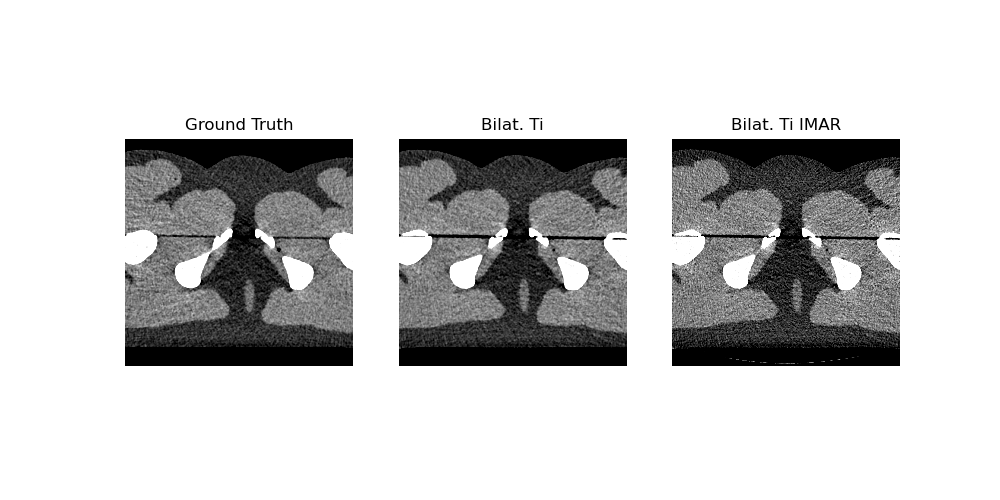

In [16]:

c, d = 100, 400
c2, d2 = int(1.5*c), int(1.5*d)

fig = plt.figure(figsize=(10,5))
plt.subplot(131)
cont = pli.hyperslicer(volume_red_normal[:,c:d,c:d],
                vmin=l-w/2,vmax=l+w/2,cmap='gray')

pli.hyperslicer(mask[:,c:d,c:d],
                vmin=0,vmax=1,controls=cont,alpha=0.75,cmap='jet')
pli.hyperslicer(mask2[:,c:d,c:d],
                vmin=1,vmax=2,controls=cont,alpha=0.75,cmap='jet')
plt.title('Ground Truth')
plt.axis('off')
plt.subplot(132)
pli.hyperslicer(volume_red_normal_Al[:,c:d,c:d],
                vmin=l-w/2,vmax=l+w/2,cmap='gray',controls= cont)

pli.hyperslicer(mask3[:,c:d,c:d],
                vmin=1,vmax=2,controls=cont,alpha=0.75,cmap='jet')
pli.hyperslicer(mask4[:,c:d,c:d],
                vmin=0,vmax=1,controls=cont,alpha=0.75,cmap='jet')
plt.title('Bilat. Ti')
plt.axis('off')

plt.subplot(133)
pli.hyperslicer(volume_red_normal_Al_IMAR[:,c2:d2,c2:d2],
                vmin=l-w/2,vmax=l+w/2,cmap='gray',controls= cont)

pli.hyperslicer(mask5[:,c2:d2,c2:d2],
                vmin=1,vmax=2,controls=cont,alpha=0.75,cmap='jet')
pli.hyperslicer(mask6[:,c2:d2,c2:d2],
                vmin=0,vmax=1,controls=cont,alpha=0.75,cmap='jet')
plt.title('Bilat. Ti IMAR')
plt.axis('off')

In [17]:
# save as a gif
cont.save_animation("double_ti_seg_comparison.gif", fig, "axis0", interval=100)

(-0.5, 449.5, 449.5, -0.5)

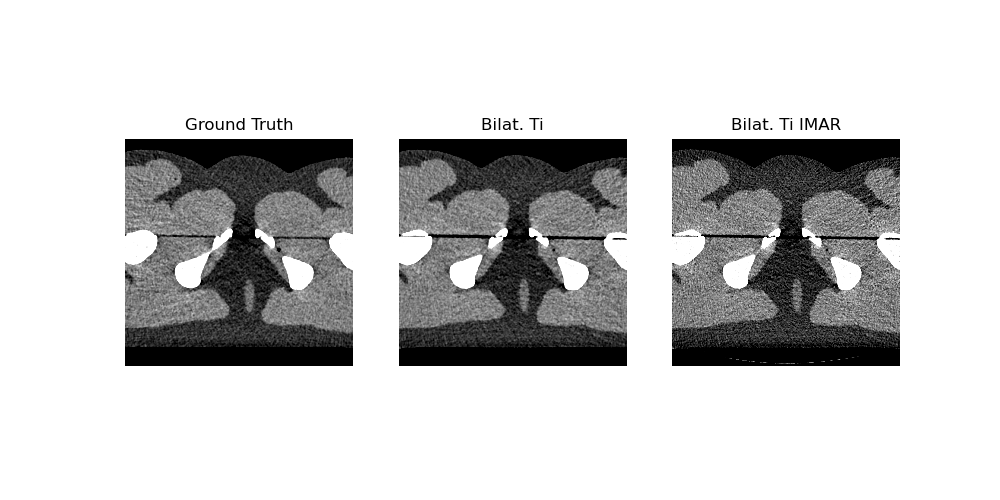

In [18]:

c, d = 100, 400
c2, d2 = int(1.5*100), int(1.5*400)

fig = plt.figure(figsize=(10,5))
plt.subplot(131)
cont = pli.hyperslicer(volume_red_normal[:,c:d,c:d],
                vmin=l-w/2,vmax=l+w/2,cmap='gray')

# pli.hyperslicer(mask[:,c:d,c:d],
#                 vmin=0,vmax=1,controls=cont,alpha=0.75,cmap='jet')
# pli.hyperslicer(mask2[:,c:d,c:d],
#                 vmin=1,vmax=2,controls=cont,alpha=0.75,cmap='jet')
plt.title('Ground Truth')
plt.axis('off')
plt.subplot(132)
pli.hyperslicer(volume_red_normal_Al[:,c:d,c:d],
                vmin=l-w/2,vmax=l+w/2,cmap='gray',controls= cont)

# pli.hyperslicer(mask3[:,c:d,c:d],
#                 vmin=1,vmax=2,controls=cont,alpha=0.75,cmap='jet')
# pli.hyperslicer(mask4[:,c:d,c:d],
#                 vmin=0,vmax=1,controls=cont,alpha=0.75,cmap='jet')
plt.title('Bilat. Ti')
plt.axis('off')

plt.subplot(133)
pli.hyperslicer(volume_red_normal_Al_IMAR[:,c2:d2,c2:d2],
                vmin=l-w/2,vmax=l+w/2,cmap='gray',controls= cont)

# pli.hyperslicer(mask5[:,c2:d2,c2:d2],
#                 vmin=1,vmax=2,controls=cont,alpha=0.75,cmap='jet')
# pli.hyperslicer(mask6[:,c2:d2,c2:d2],
#                 vmin=0,vmax=1,controls=cont,alpha=0.75,cmap='jet')
plt.title('Bilat. Ti IMAR')
plt.axis('off')

In [19]:
# save as a gif
cont.save_animation("double_ti_comparison.gif", fig, "axis0", interval=100)

(-0.5, 149.5, 149.5, -0.5)

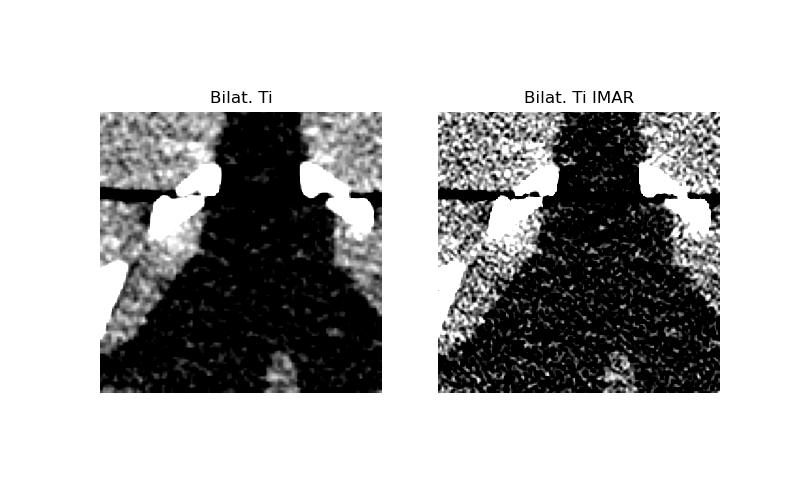

In [21]:

w,l = 200, 35
c, d = 200, 300
c2, d2 = int(1.5*c), int(1.5*d)

fig = plt.figure(figsize=(8,5))
# plt.subplot(131)
# cont = pli.hyperslicer(volume_red_normal[:,c:d,c:d],
#                 vmin=l-w/2,vmax=l+w/2,cmap='gray')

# pli.hyperslicer(mask[:,c:d,c:d],
#                 vmin=0,vmax=1,controls=cont,alpha=0.75,cmap='jet')
# pli.hyperslicer(mask2[:,c:d,c:d],
#                 vmin=1,vmax=2,controls=cont,alpha=0.75,cmap='jet')
# plt.title('Ground Truth')
# plt.axis('off')
plt.subplot(121)
cont = pli.hyperslicer(volume_red_normal_Al[:,c:d,c:d],
                vmin=l-w/2,vmax=l+w/2,cmap='gray')

# pli.hyperslicer(mask3[:,c:d,c:d],
#                 vmin=1,vmax=2,controls=cont,alpha=0.75,cmap='jet')
# pli.hyperslicer(mask4[:,c:d,c:d],
#                 vmin=0,vmax=1,controls=cont,alpha=0.75,cmap='jet')
plt.title('Bilat. Ti')
plt.axis('off')

plt.subplot(122)
pli.hyperslicer(volume_red_normal_Al_IMAR[:,c2:d2,c2:d2],
                vmin=l-w/2,vmax=l+w/2,cmap='gray',controls= cont)

# pli.hyperslicer(mask5[:,c2:d2,c2:d2],
#                 vmin=1,vmax=2,controls=cont,alpha=0.75,cmap='jet')
# pli.hyperslicer(mask6[:,c2:d2,c2:d2],
#                 vmin=0,vmax=1,controls=cont,alpha=0.75,cmap='jet')
plt.title('Bilat. Ti IMAR')
plt.axis('off')

In [22]:
# save as a gif
cont.save_animation("double_ti_comparison_tight.gif", fig, "axis0", interval=100)

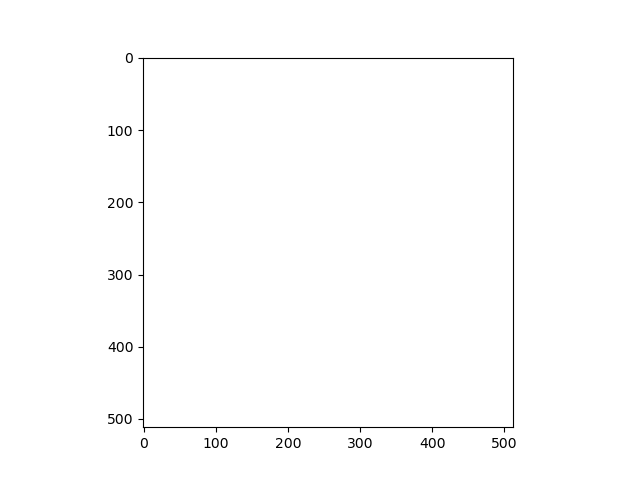

In [30]:
plt.figure()
pli.hyperslicer(mask)

In [12]:
ndimage.bin

Signature:
pli.hyperslicer(
    arr,
    alpha=None,
    vmin=None,
    vmax=None,
    vmin_vmax=None,
    autoscale_cmap=True,
    ax=None,
    slider_formats=None,
    title=None,
    force_ipywidgets=False,
    play_buttons=False,
    is_color_image=False,
    controls=None,
    display_controls=True,
    **kwargs,
)
Docstring:
View slices from a hyperstack of images selected by sliders.

Also accepts Xarray.DataArrays in which case the axes names and coordinates
will be inferred from the xarray dims and coords.

Parameters
----------
arr : arraylike or xarray
    Hyperstack of images. The last 2 or 3 dimensions will be treated as individiual images.
    If an xarray.DataArray then the dimensions will be automatically inferred.
alpha : float, Callable or widget shorthand, indexed controls, optional
    The alpha of the image. If a callable then it will receive parameters be autoupdated.
    Can also be given a widget shorthand to automatically generate a slider
    (e.g. `alpha = (0

In [52]:
CT_4 = volume4.T[80:150, 200:320, 200:300] + 1000

CT_1 = volume1.T[600:882, 170:290, 210:310] + 1000
CT_1 = (CT_1[::3] + CT_1[1::3]  + CT_1[2::3]) /3
CT_1 = (CT_1[:,::2] + CT_1[:,1::2]) /2

CNR for bladder in PCCT: 3.212501087011755
CNR for bladder in EICT: 0.42820557075318544


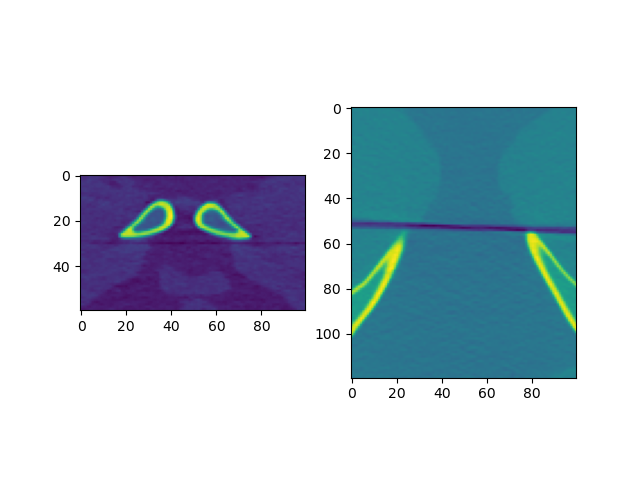

In [19]:
plt.figure()
plt.subplot(121)
pli.hyperslicer(CT_1)#[39:63,17:25,28:45])
plt.subplot(122)
pli.hyperslicer(CT_4)#[39:47,28:48,33:53])

bladder_pcct = CT_1[39:45,17:25,28:45]
bladder_eict = CT_4[39:41,28:48,33:53]

ref_pcct = CT_1[46:61,:5,:50]
ref_eict = CT_4[42:46,:5,:50]

# compute the contrast to noise ratio in the bladder for the pcct and eict
mean_bladder_pcct = np.mean(bladder_pcct)
mean_bladder_eict = np.mean(bladder_eict)

std_bladder_pcct = np.std(bladder_pcct)
std_bladder_eict = np.std(bladder_eict)

mean_muscle_pcct = np.mean(ref_pcct)
mean_muscle_eict = np.mean(ref_eict)

std_muscle_pcct = np.std(ref_pcct)
std_muscle_eict = np.std(ref_eict)

CNR_bladder_pcct = np.abs(mean_bladder_pcct - mean_muscle_pcct) / (std_bladder_pcct**2)**0.5
CNR_bladder_eict = np.abs(mean_bladder_eict - mean_muscle_eict) / (std_bladder_eict**2)**0.5

print(f'CNR for bladder in PCCT: {CNR_bladder_pcct}')
print(f'CNR for bladder in EICT: {CNR_bladder_eict}')

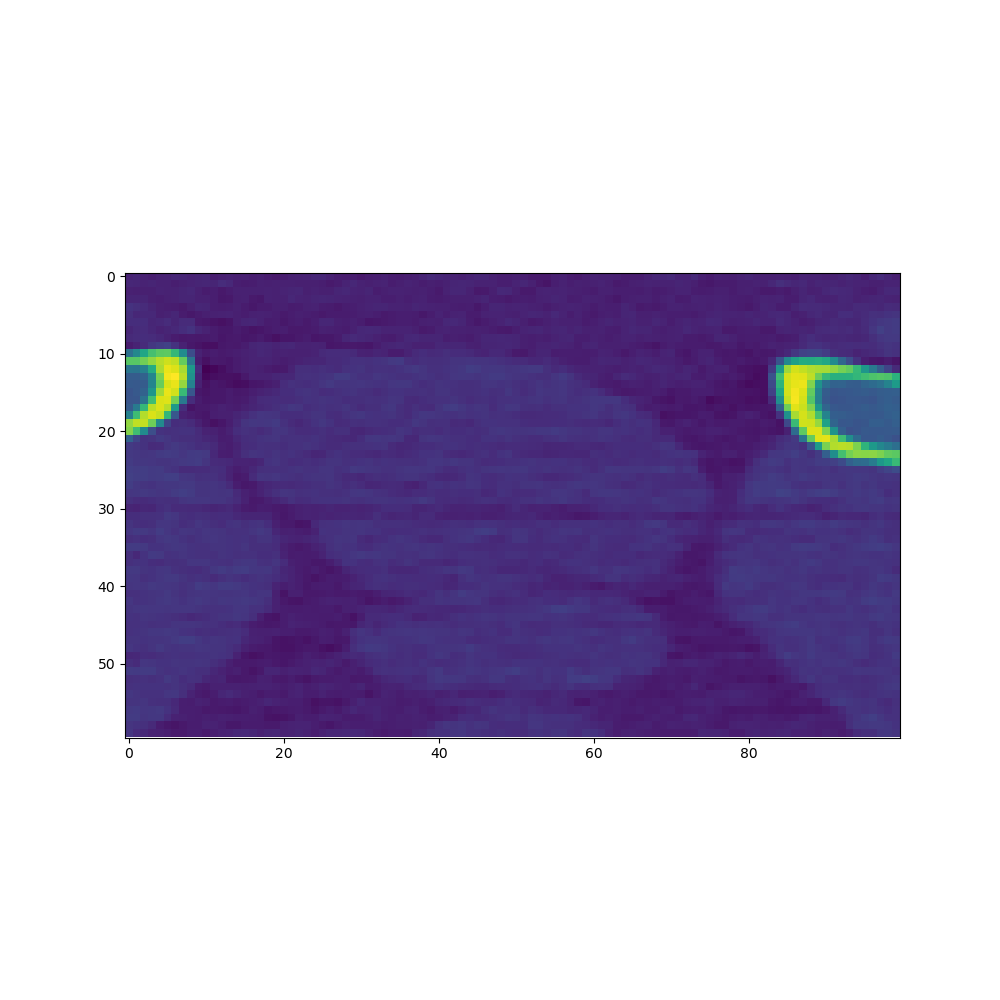

In [58]:
# plt.figure()
mask_bladder1 = pli.image_segmenter(CT_1[47])
display(mask_bladder1)

In [59]:
bladder_seg1 = mask_bladder1.mask

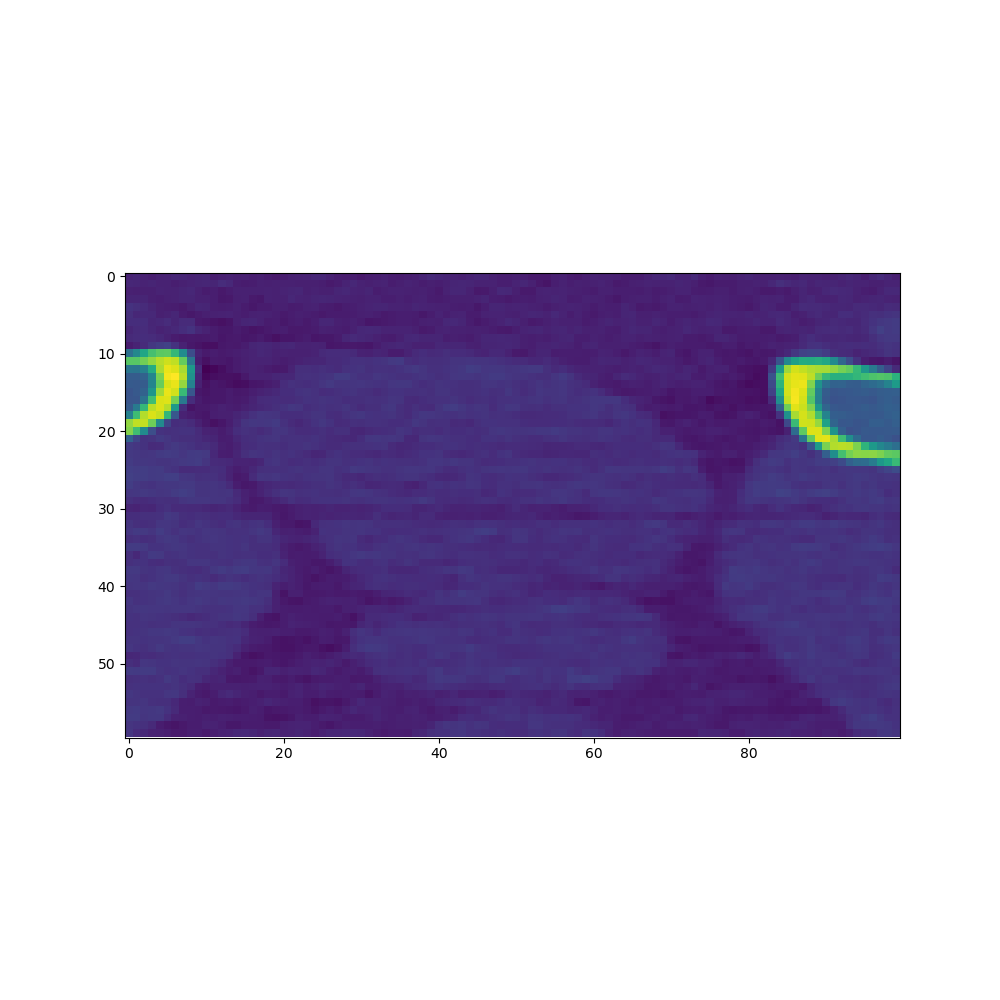

In [60]:
mask_bg1 = pli.image_segmenter(CT_1[47])
display(mask_bg1)

In [61]:
bg_seg1 = mask_bg1.mask

In [83]:
# apply a gaussian filter to the CT_1 image
from scipy.ndimage import gaussian_filter

CT_1_gauss = gaussian_filter(np.mean(CT_1[46:48],axis=0) , sigma=1.5)


contrast = np.mean(CT_1_gauss[bladder_seg1.astype(bool)]) - np.mean(CT_1_gauss[bg_seg1.astype(bool)])
noise = np.std(CT_1_gauss[bladder_seg1.astype(bool)])

CNR = contrast / noise
print(f'CNR for bladder in PCCT: {CNR} and contrast: {contrast} and noise: {noise}')

CNR for bladder in PCCT: 13.606209876829354 and contrast: 85.55813407584094 and noise: 6.288168038738095


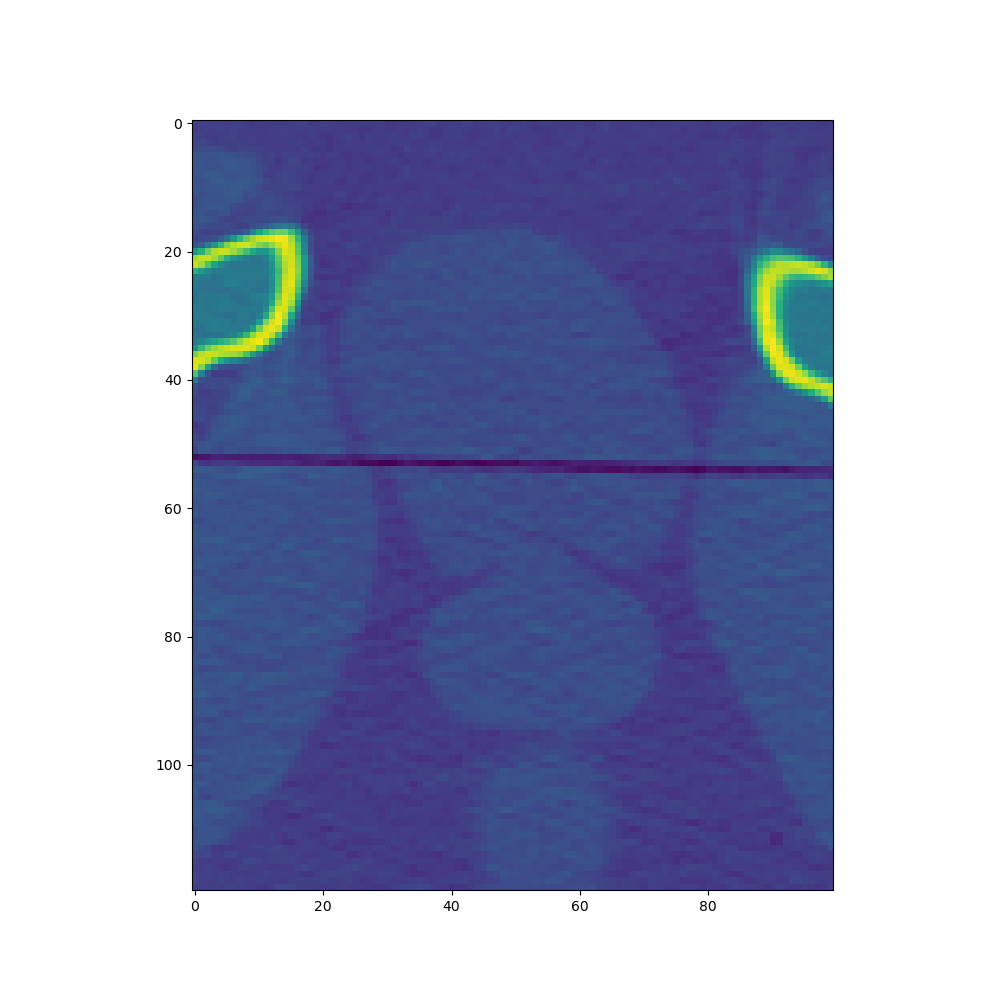

In [63]:
# plt.figure()
mask_bladder = pli.image_segmenter(CT_4[40])
display(mask_bladder)

In [64]:
bladder_seg = mask_bladder.mask

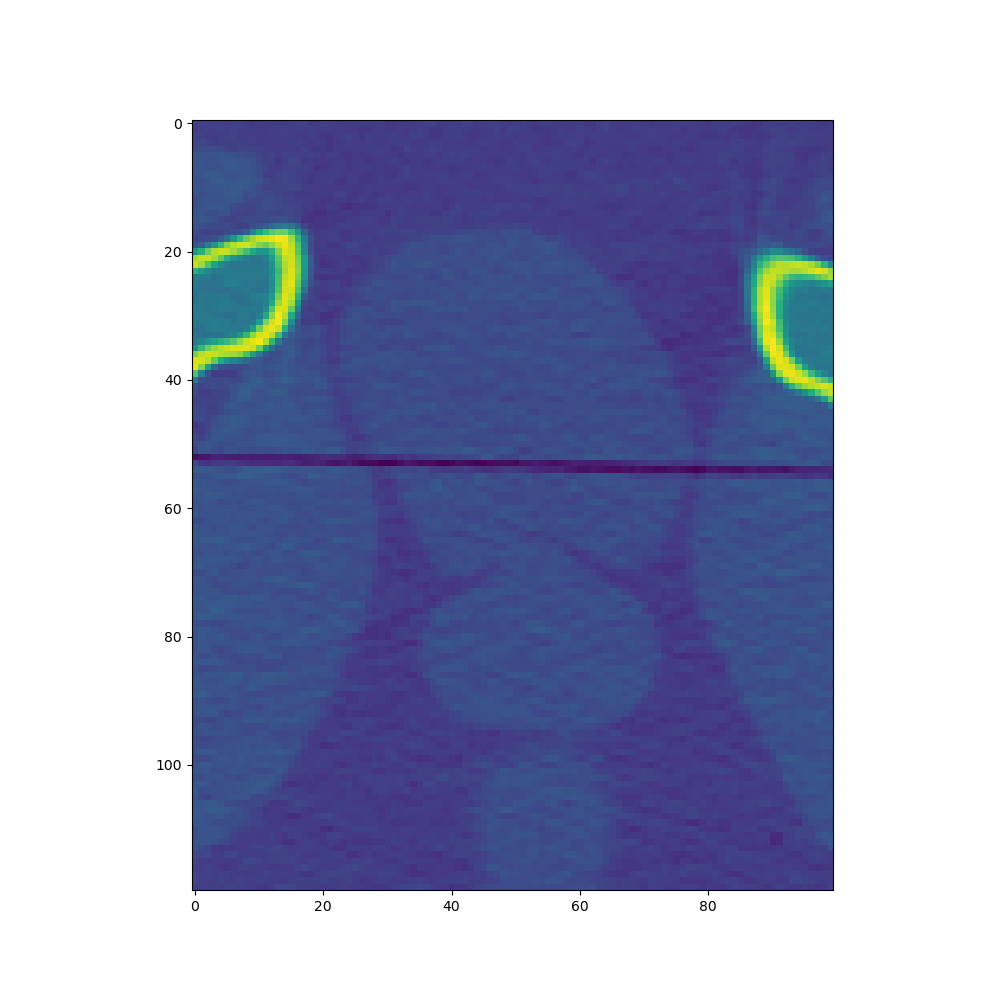

In [65]:
mask_bg = pli.image_segmenter(CT_4[40])
display(mask_bg)

In [81]:
bg_seg = mask_bg.mask

# apply a gaussian filter to the CT_1 image
from scipy.ndimage import gaussian_filter

CT_4_gauss = gaussian_filter(CT_4[40], sigma=1.5)

contrast = np.mean(CT_4_gauss[bladder_seg.astype(bool)]) - np.mean(CT_4_gauss[bg_seg.astype(bool)])
noise = np.std(CT_4_gauss[bladder_seg.astype(bool)])

CNR = contrast / noise
print(f'CNR for bladder in EICT: {CNR} and contrast: {contrast} and noise: {noise}')

CNR for bladder in EICT: 13.799366127661727 and contrast: 84.84126913820842 and noise: 6.148200457420908


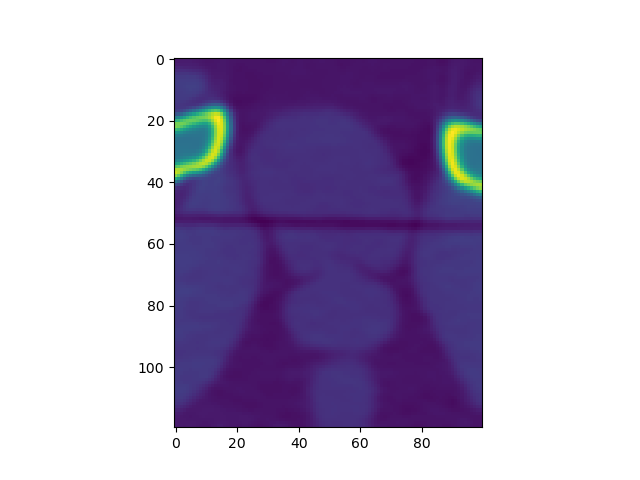

In [67]:
plt.figure()
plt.imshow(CT_4_gauss)

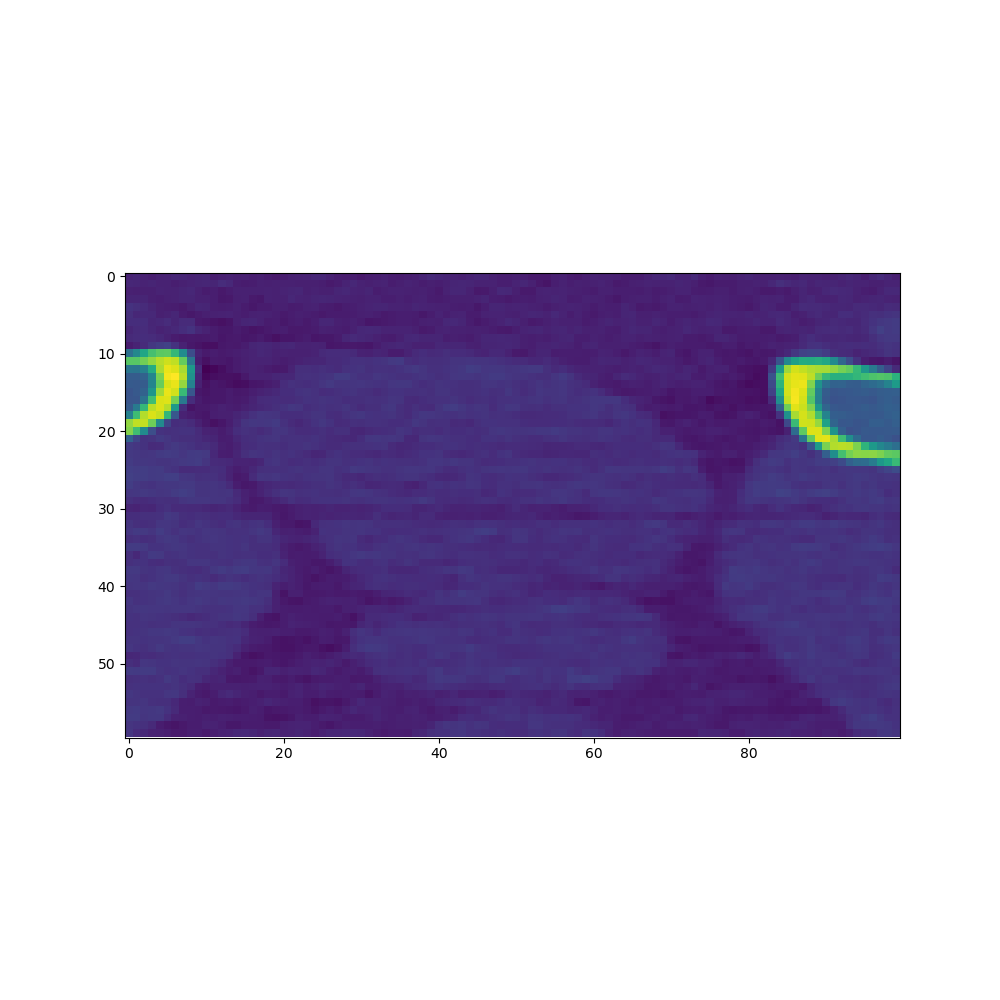

In [72]:
## Segment the prostate

mask_prostate1 = pli.image_segmenter(CT_1[47])
display(mask_prostate1)

In [74]:
prostate_seg1 = mask_prostate1.mask

In [82]:
contrast = np.mean(CT_1_gauss[prostate_seg1.astype(bool)]) - np.mean(CT_1_gauss[bg_seg1.astype(bool)])
noise = np.std(CT_1_gauss[prostate_seg1.astype(bool)])

CNR = contrast / noise
print(f'CNR for prostate in PCCT: {CNR} and contrast: {contrast} and noise: {noise}')

CNR for prostate in PCCT: 17.716170690392897 and contrast: 90.11088262888995 and noise: 5.086363424899444


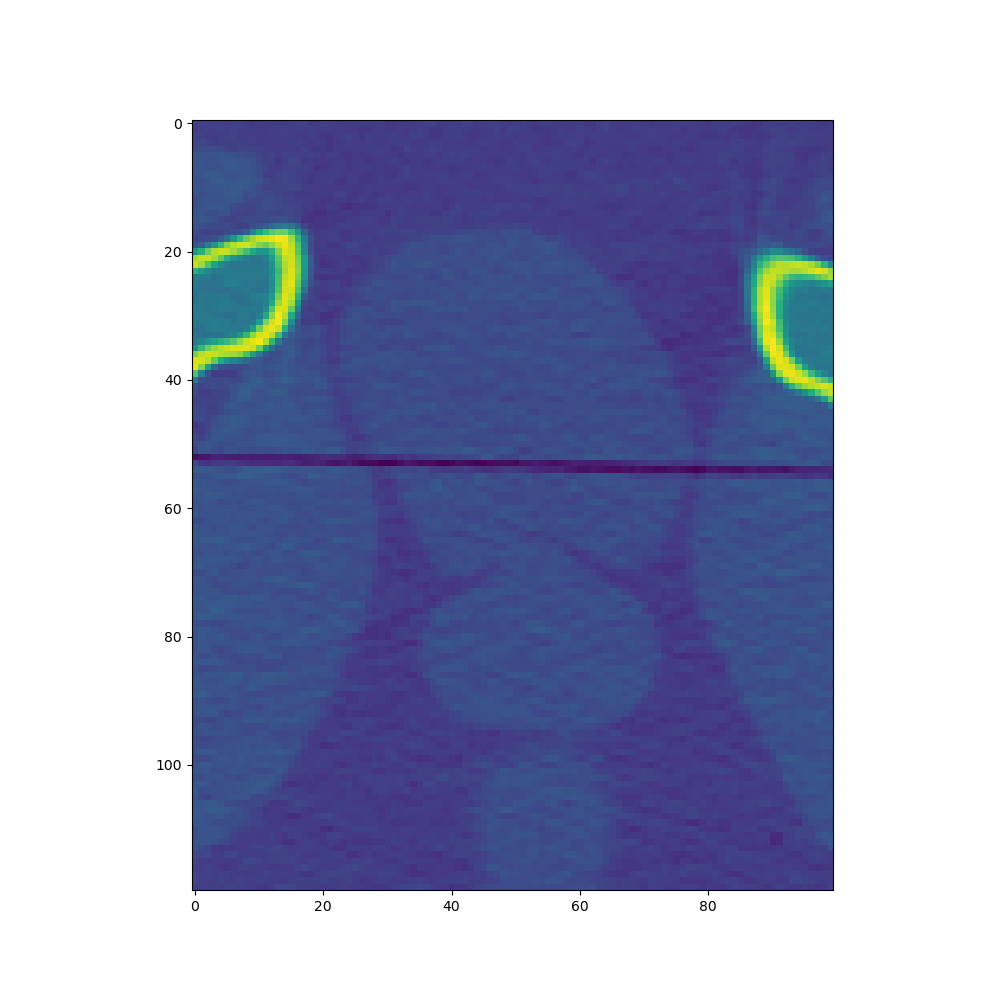

In [78]:
# segment the prostate in the EICT
mask_prostate = pli.image_segmenter(CT_4[40])
display(mask_prostate)

In [79]:

prostate_seg = mask_prostate.mask

In [80]:
contrast = np.mean(CT_4_gauss[prostate_seg.astype(bool)]) - np.mean(CT_4_gauss[bg_seg.astype(bool)])
noise = np.std(CT_4_gauss[prostate_seg.astype(bool)])

CNR = contrast / noise
print(f'CNR for prostate in EICT: {CNR}')

CNR for prostate in EICT: 20.31460337971465
